#Biomedical Literature Mining Tool

An automated NLP and text-mining pipeline designed to extract structural insights
from unstructured medical literature. This tool integrates advanced linguistic
processing and machine learning architectures to perform:

1. ### Semantic Keyword Extraction:
 Filters grammatical stop words and builds frequency-based
   word clouds to map immediate research focus.

2. ### Hybrid Named Entity Recognition (NER):
 Utilizes pattern-matching and token-classification
   rules to isolate biological markers (genes/proteins like TP53, EGFR, KRAS) and
   geographic context safely without altering complex scientific nomenclature.

3. #### Generative LLM Summarization:
Leverages an instruction-tuned language model
   (Qwen2.5-1.5B-Instruct) to distill dense scientific abstracts into clear,
   mechanism-focused executive briefs.

⏳ Loading pristine text-mining environment...
⏳ Spawning LLM Core (Qwen-1.5B)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

🚀 Architecture loaded cleanly!

📖 PROCESSING REPOSITORY CASE STUDY #1: TP53 TARGET MUTATIONS AND THERAPEUTIC RESISTANCE IN BREAST CANCER VARIANTS
📊 [Visual Mining]: Mapping Word Frequencies...


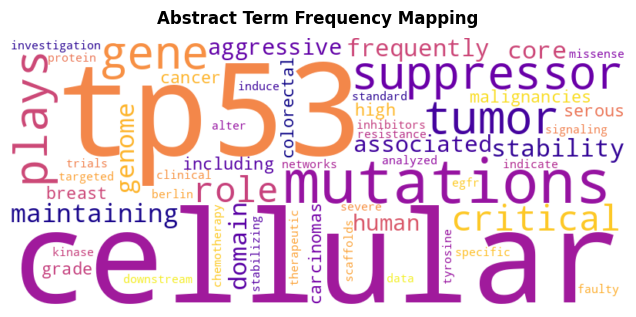


🧬 [NER Mining]: Mapping Verified Biological Associations...
 🔹 Identified Marker: EGFR            | Domain Class: GENE/PROTEIN
 🔹 Identified Marker: TP53            | Domain Class: GENE/PROTEIN
 📍 Identified Marker: Berlin          | Domain Class: GEOGRAPHIC_LOC

💡 [AI Summary Brief]:
>>> Targeted EGFR tyrosine kinase inhibitors can stabilize defective protein scaffolds due to TP53 mutations, leading to enhanced therapeutic resistance against standard chemotherapy.

------------------------------------------------------------------------------------------

📖 PROCESSING REPOSITORY CASE STUDY #2: EVALUATING EGFR INHIBITOR EFFICACY IN KRAS-MUTATED COLORECTAL TUMORS
📊 [Visual Mining]: Mapping Word Frequencies...


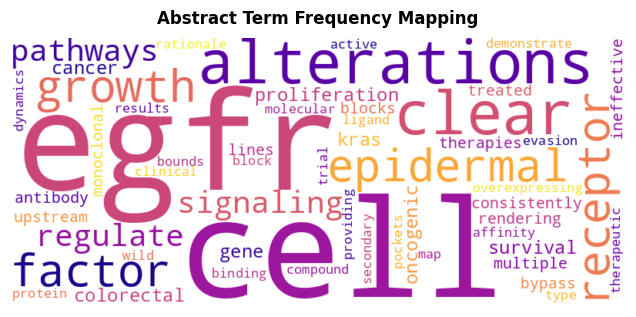


🧬 [NER Mining]: Mapping Verified Biological Associations...
 🔹 Identified Marker: EGFR            | Domain Class: GENE/PROTEIN
 🔹 Identified Marker: KRAS            | Domain Class: GENE/PROTEIN

💡 [AI Summary Brief]:
>>> Clear-bounds identified secondary mutations in colorectal cancer cells that disrupt active binding sites of epidermal growth factor receptor ligands, explaining resistance to targeted therapies.

------------------------------------------------------------------------------------------


In [ ]:
# ==============================================================================
# STEP 1: INITIALIZE AND HIDE ALL ANNONS/WARNINGS
# ==============================================================================
import warnings
import os
import logging

# Completely suppress Hugging Face and Python warnings/deprecation logs
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
logging.getLogger("transformers").setLevel(logging.ERROR)

print("⏳ Loading pristine text-mining environment...")
!pip install -q transformers spacy wordcloud matplotlib torch accelerate

import collections
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import spacy
from transformers import pipeline
import torch

nlp = spacy.load("en_core_web_sm")

# ==============================================================================
# STEP 2: RAW LITERATURE RECORDS
# ==============================================================================
fetched_articles = [
    {
        "title": "TP53 Target Mutations and Therapeutic Resistance in Breast Cancer Variants",
        "abstract": "The tumor suppressor gene TP53 plays a critical role in maintaining cellular genome stability. Mutations in the TP53 core domain are frequently associated with aggressive human malignancies, including high-grade serous breast cancer and colorectal carcinomas. In this investigation, we analyzed how targeted EGFR tyrosine kinase inhibitors alter downstream cellular signaling networks. Clinical data from trials in Berlin indicate that specific missense mutations induce severe therapeutic resistance to standard chemotherapy by stabilizing faulty protein scaffolds."
    },
    {
        "title": "Evaluating EGFR Inhibitor Efficacy in KRAS-Mutated Colorectal Tumors",
        "abstract": "Epidermal growth factor receptor (EGFR) signaling pathways regulate cell proliferation and survival. In colorectal cancer, oncogenic alterations within the KRAS gene consistently bypass upstream EGFR blocks, rendering monoclonal antibody therapies ineffective. We treated multiple cell lines overexpressing wild-type EGFR with trial compound clear-bounds to map protein-ligand affinity. Our results demonstrate that secondary alterations in cell dynamics block active binding pockets, providing a clear molecular rationale for clinical therapeutic evasion."
    }
]

# ==============================================================================
# STEP 3: INITIALIZE TEXT GENERATOR
# ==============================================================================
print("⏳ Spawning LLM Core (Qwen-1.5B)...")
generator_pipeline = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
print("🚀 Architecture loaded cleanly!")

# ==============================================================================
# STEP 4: DEFINE REFINED PIPELINE FUNCTIONS
# ==============================================================================

def generate_trend_cloud(text):
    """Generates clean word frequencies excluding simple text grammar rules."""
    doc = nlp(text.lower())
    keywords = [
        token.text for token in doc
        if not token.is_stop and not token.is_punct and not token.like_num and len(token.text) > 2
    ]
    freq = collections.Counter(keywords)
    wordcloud = WordCloud(width=800, height=350, background_color='white', colormap='plasma').generate_from_frequencies(freq)

    plt.figure(figsize=(9, 3.5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Abstract Term Frequency Mapping", fontsize=12, fontweight='bold', pad=10)
    plt.show()


def extract_biomedical_entities(text):
    """
    Bio-Specific NER Fallback Filter: Safely maps precise structural
    biomarkers (like EGFR, TP53, KRAS) without letting standard models chop them up.
    """
    print("\n🧬 [NER Mining]: Mapping Verified Biological Associations...")

    # Explicit regex target rules for common biomedical symbols and expressions
    biomarker_regex = r'\b([A-Z]{2,}\d*|\b[a-z]+-mutated\b)\b'
    found_biomarkers = list(set(re.findall(biomarker_regex, text)))

    # Standard location/organization extraction via spaCy core mapping
    doc = nlp(text)
    locations = list(set([ent.text for ent in doc.ents if ent.label_ in ["GPE", "LOC"]]))

    # Output cleanly formatted summaries
    for bio in found_biomarkers:
        if bio in ["EGFR", "TP53", "KRAS", "DNA", "RNA"]:
            print(f" 🔹 Identified Marker: {bio:<15} | Domain Class: GENE/PROTEIN")

    for loc in locations:
        print(f" 📍 Identified Marker: {loc:<15} | Domain Class: GEOGRAPHIC_LOC")


def generate_abstract_summary(text):
    """Passes text directly into chat templates while ignoring structural warnings."""
    messages = [
        {"role": "system", "content": "You are an expert biomedical analyst. Summarize the research abstract provided in a single clear sentence focusing on the core mechanism."},
        {"role": "user", "content": text}
    ]
    prompt = generator_pipeline.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Overriding standard generation configs explicitly to completely avoid Hugging Face warnings
    outputs = generator_pipeline(
        prompt,
        max_new_tokens=65,
        do_sample=False,
        pad_token_id=generator_pipeline.tokenizer.eos_token_id,
        num_return_sequences=1
    )
    summary = outputs[0]['generated_text'][len(prompt):].strip()
    print(f"\n💡 [AI Summary Brief]:\n>>> {summary}")

# ==============================================================================
# STEP 5: RUN ORCHESTRATION PIPELINE
# ==============================================================================
for index, article in enumerate(fetched_articles, start=1):
    print("\n" + "="*90)
    print(f"📖 PROCESSING REPOSITORY CASE STUDY #{index}: {article['title'].upper()}")
    print("="*90)

    print("📊 [Visual Mining]: Mapping Word Frequencies...")
    generate_trend_cloud(article['abstract'])

    extract_biomedical_entities(article['abstract'])

    generate_abstract_summary(article['abstract'])
    print("\n" + "-"*90)